# Analyze ECMs and compute community modes

Takes the raw ecmtool output (per species, per exchange pattern, per growth rate) and:

1. Normalizes each ECM by the `constraint_reaction` flux, and filters out unrealistic (non-growing, extreme-flux > 1000) solutions.
2. Filters ECMs down to the ones matching each pattern's intended cross-feeding scenario.
3. Plots secretion/biomass yield trade-offs.
4. Combines Geobacter's and Rhodoferax's filtered ECMs into one exchange-only stoichiometric system and runs efmtool on it, to get elementary community modes (community composition per growth rate).

In [1]:
import re
import pickle
import efmtool
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load run metadata

Everything about how the models were built - growth rates tested, the exchange patterns, and the fixed uptake rate - comes from `run_metadata.pkl`, written by `make_ecmtool_inputs.ipynb`.

In [2]:
with open("../run_metadata.pkl", "rb") as f:
    run_metadata = pickle.load(f)

simulated_mus = run_metadata["simulated_mus"]
FIXED_UPTAKE = run_metadata["fixed_uptake"]
c_sources = run_metadata["c_sources"]
exchange_pattern = run_metadata["exchange_pattern"]

### Convert to ecmtool's metabolite id form

`exchange_pattern` and `c_sources` use SBML reaction ids (e.g. `EX_mal-L_e`); ecmtool's output uses the corresponding metabolite ids (e.g. `M_mal__45__L_e`). Both are derived here from the same `exchange_pattern`/`c_sources` metadata, so there is one conversion function instead of two copies of it.

In [3]:
def to_metabolite_id(ex_id):
    """Convert an exchange reaction id to ecmtool's metabolite id form.
    e.g. 'EX_mal-L_e' -> 'M_mal__45__L_e'
    """
    return ex_id.replace("EX_", "M_", 1).replace("-", "__45__")


def get_c_sources(exchange_pattern, c_sources):
    """For each organism/pattern, return the one uptake reaction that is
    also a carbon source, converted to ecmtool's metabolite id form.
    """
    c_sources = set(c_sources)
    result = {}
    for organism, patterns in exchange_pattern.items():
        result[organism] = {}
        for pattern_name, pattern in patterns.items():
            found = sorted(set(pattern["uptakes"]) & c_sources)
            if len(found) != 1:
                raise ValueError(
                    f"Expected exactly one carbon source in {organism}/{pattern_name}, got {found}"
                )
            result[organism][pattern_name] = to_metabolite_id(found[0])
    return result


def convert_exchange_pattern(exchange_pattern):
    return {
        organism: {
            pattern_name: {
                key: [to_metabolite_id(ex_id) for ex_id in ids]
                for key, ids in pattern.items()
            }
            for pattern_name, pattern in patterns.items()
        }
        for organism, patterns in exchange_pattern.items()
    }


c_sources = get_c_sources(exchange_pattern, c_sources)
converted_pattern = convert_exchange_pattern(exchange_pattern)
c_sources

{'Rhodoferax': {'mEmC_1': 'M_fum_e',
  'mEmC_3': 'M_fum_e',
  'mEmC_2': 'M_cit_e',
  'mEmC_4': 'M_cit_e',
  'mEmC_5': 'M_mal__45__L_e',
  'mEmC_6': 'M_mal__45__L_e',
  'mE_1': 'M_ac_e'},
 'Geobacter': {'mEmC_1': 'M_mal__45__L_e',
  'mEmC_2': 'M_mal__45__L_e',
  'mEmC_3': 'M_mal__45__L_e',
  'mEmC_4': 'M_mal__45__L_e',
  'mEmC_5': 'M_cit_e',
  'mEmC_6': 'M_cit_e',
  'mE_1': 'M_mal__45__L_e'}}

### Filter to growing, well-scaled ECMs

For each species/pattern/growth rate: keep only ECMs with nonzero growth, normalize by the `constraint_reaction` tag flux (fixed at 1 by construction, so this rescales every other flux to the values it actually represents), drop ECMs with implausibly large fluxes (an artifact of the bound-free conversion), and recover the true carbon-source uptake flux from `M_fixed_uptake` (removed during that same conversion).

In [4]:
growing_ecms = {}
for organism in ["Rhodoferax", "Geobacter"]:
    print(f" * {organism}")
    growing_ecms[organism] = {}

    for pattern_name, growth_rates in simulated_mus.items():
        print(pattern_name)
        growing_ecms[organism][pattern_name] = {}

        for mu in growth_rates:
            mu = round(mu, 2)
            print(f"Growth rate {mu}")
            ecms = pd.read_csv(f"../results/{organism}_{pattern_name}_{mu}_full_conversions.csv")

            # keep only ECMs that grow
            growing = ecms[ecms["objective"] > 1e-9]
            print(f"  * {len(growing)}/{len(ecms)} growing ECMs")

            # divide by constraint reaction - it must have flux of 1 so that constraints work
            growing = growing.div(growing["virtual_tag_R_constraint_reaction"], axis=0)

            # remove extreme fluxes
            growing = growing[(growing.abs() <= 1000).all(axis=1)]
            print(f"  * {len(growing)} growing ECMs after filtering extreme fluxes")

            # add back the uptake reaction (dropped from ecmtool's output because of the bound-free form)
            growing[c_sources[organism][pattern_name]] = -FIXED_UPTAKE - growing["M_fixed_uptake"]
            growing = growing.drop(columns=["M_fixed_uptake"])

            growing_ecms[organism][pattern_name][mu] = growing
            #growing.to_csv(f"../results/growing_ecms_{organism}_{pattern_name}_{mu}.csv")

 * Rhodoferax
mEmC_1
Growth rate 0.66
  * 12/13 growing ECMs
  * 12 growing ECMs after filtering extreme fluxes
Growth rate 0.6
  * 70/71 growing ECMs
  * 70 growing ECMs after filtering extreme fluxes
Growth rate 0.54
  * 72/73 growing ECMs
  * 72 growing ECMs after filtering extreme fluxes
Growth rate 0.47
  * 72/73 growing ECMs
  * 72 growing ECMs after filtering extreme fluxes
Growth rate 0.4
  * 72/73 growing ECMs
  * 72 growing ECMs after filtering extreme fluxes
Growth rate 0.33
  * 190/191 growing ECMs
  * 190 growing ECMs after filtering extreme fluxes
Growth rate 0.27
  * 267/268 growing ECMs
  * 267 growing ECMs after filtering extreme fluxes
Growth rate 0.2
  * 319/320 growing ECMs
  * 319 growing ECMs after filtering extreme fluxes
mEmC_3
Growth rate 0.66
  * 12/13 growing ECMs
  * 12 growing ECMs after filtering extreme fluxes
Growth rate 0.6
  * 70/71 growing ECMs
  * 70 growing ECMs after filtering extreme fluxes
Growth rate 0.54
  * 72/73 growing ECMs
  * 72 growing EC

### Filter to the intended cross-feeding pattern

Next, we filter only the ECMs consistent with each exchange scenario, and drops any exchange columns that are all-zero afterward.

This uses the full uptake/secretion lists from `exchange_pattern` (everything constrained in `make_ecmtool_inputs.ipynb`).

In [5]:
filtered_ecms = {}
for organism, patterns in converted_pattern.items():
    filtered_ecms[organism] = {}

    for pattern_name, pattern in patterns.items():
        print(organism, pattern_name)
        filtered_ecms[organism][pattern_name] = {}

        for mu, ecms in growing_ecms[organism][pattern_name].items():
            sec_cols = pattern["secretion"]
            uptake_cols = pattern["uptakes"]

            filtered = ecms[(ecms[sec_cols] > 0).all(axis=1)]
            filtered = filtered[(filtered[uptake_cols] < 0).all(axis=1)]
            filtered = filtered.loc[:, (filtered != 0).any(axis=0)]  # drop all-zero columns

            filtered_ecms[organism][pattern_name][mu] = filtered
            filtered.to_csv(f"../results/filtered_ecms_{organism}_{pattern_name}_{mu}.csv")

            print(f"  {mu}: {len(filtered)}/{len(ecms)} ECMs")

Rhodoferax mEmC_1
  0.66: 1/12 ECMs
  0.6: 10/70 ECMs
  0.54: 12/72 ECMs
  0.47: 12/72 ECMs
  0.4: 12/72 ECMs
  0.33: 62/190 ECMs
  0.27: 66/267 ECMs
  0.2: 66/319 ECMs
Rhodoferax mEmC_3
  0.66: 1/12 ECMs
  0.6: 10/70 ECMs
  0.54: 12/72 ECMs
  0.47: 12/72 ECMs
  0.4: 12/72 ECMs
  0.33: 62/190 ECMs
  0.27: 66/267 ECMs
  0.2: 66/319 ECMs
Rhodoferax mEmC_2
  0.99: 1/13 ECMs
  0.9: 1/13 ECMs
  0.8: 1/13 ECMs
  0.7: 1/13 ECMs
  0.6: 4/44 ECMs
  0.5: 12/112 ECMs
  0.4: 22/188 ECMs
  0.3: 104/435 ECMs
Rhodoferax mEmC_4
  0.92: 1/13 ECMs
  0.84: 1/13 ECMs
  0.74: 1/13 ECMs
  0.65: 4/44 ECMs
  0.56: 8/76 ECMs
  0.47: 15/137 ECMs
  0.37: 25/207 ECMs
  0.28: 113/453 ECMs
Rhodoferax mEmC_5
  0.66: 12/12 ECMs
  0.6: 70/70 ECMs
  0.54: 72/72 ECMs
  0.47: 72/72 ECMs
  0.4: 72/72 ECMs
  0.33: 94/94 ECMs
  0.27: 154/154 ECMs
  0.2: 188/188 ECMs
Rhodoferax mEmC_6
  0.32: 4/44 ECMs
  0.29: 6/62 ECMs
  0.26: 10/94 ECMs
  0.23: 10/94 ECMs
  0.2: 12/108 ECMs
  0.16: 30/126 ECMs
  0.13: 40/164 ECMs
  0.1: 38

### Secretion vs biomass yield

For each pattern that has a secretion product, plot the yield of that product against biomass yield (both per unit carbon source), one figure per growth rate.

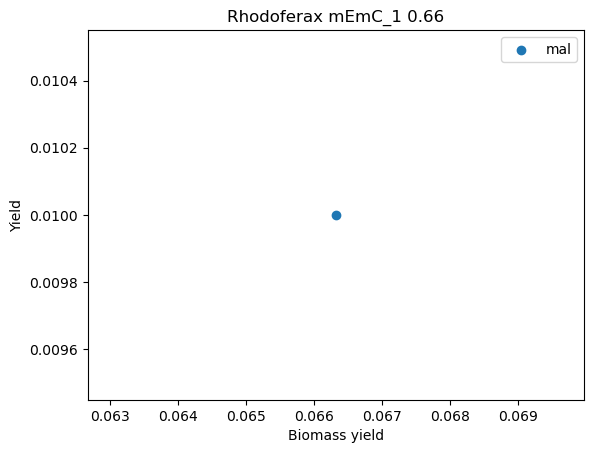

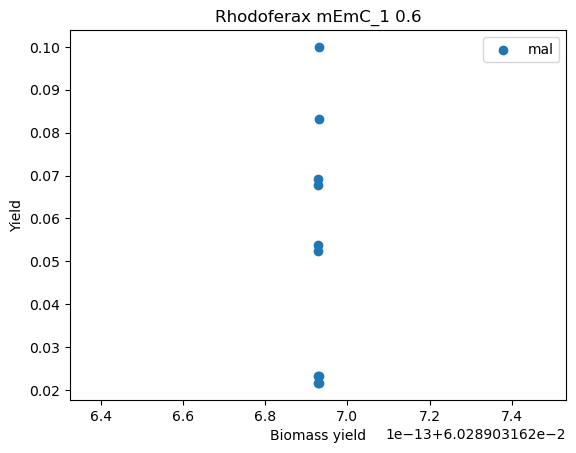

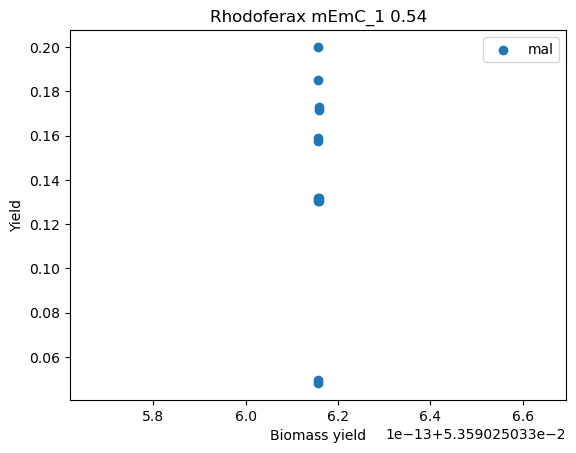

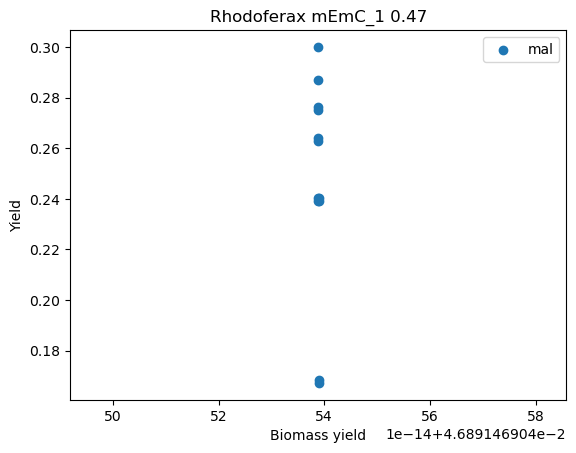

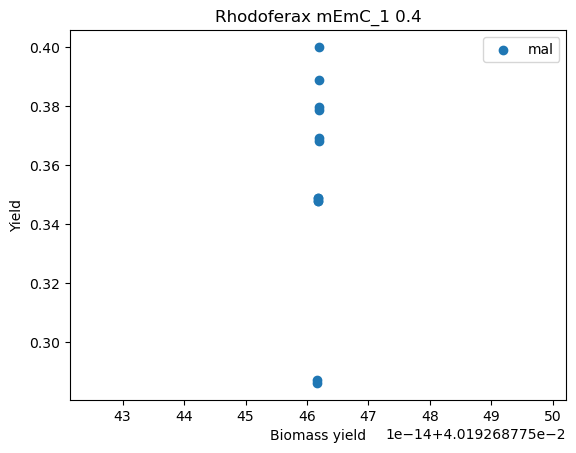

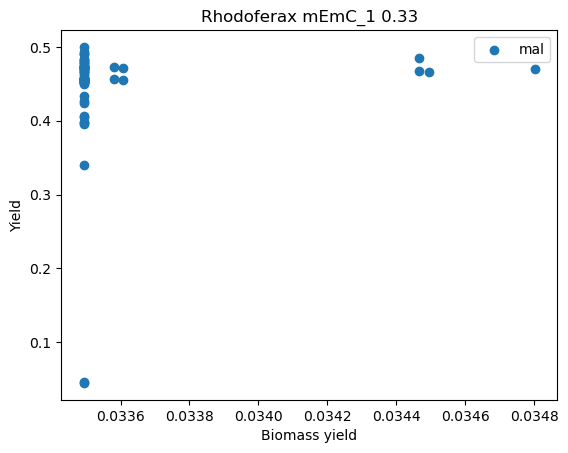

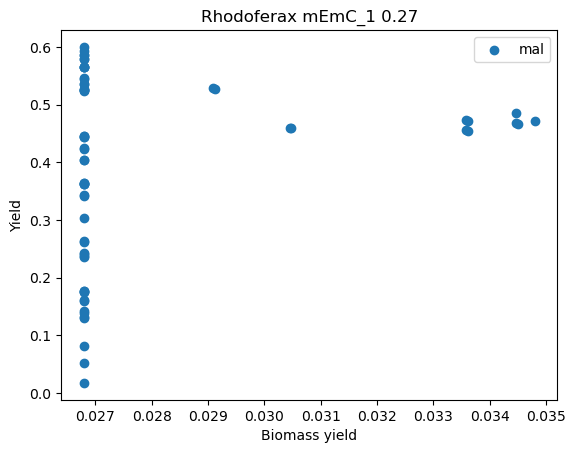

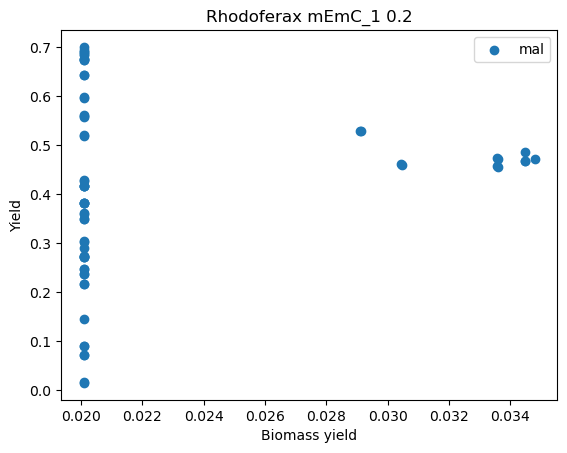

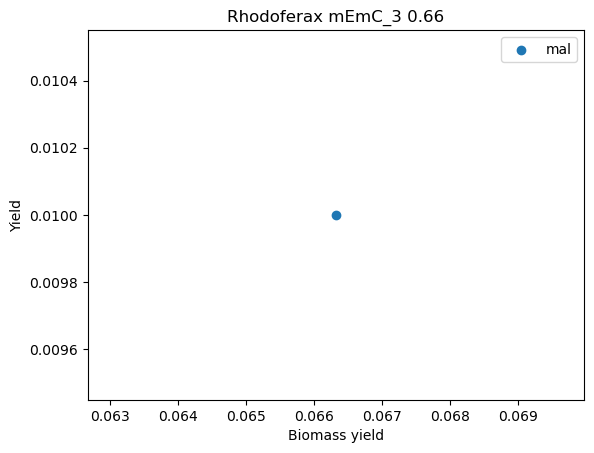

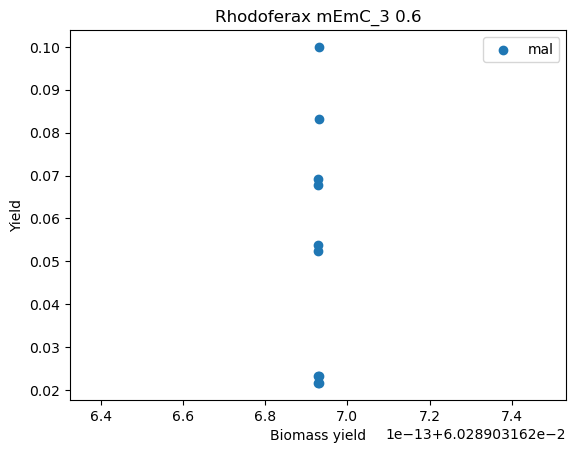

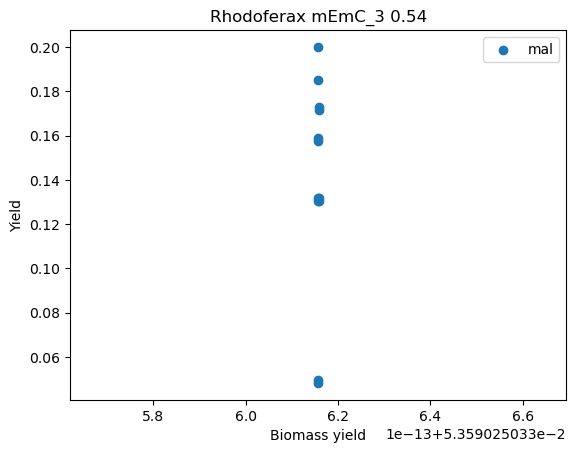

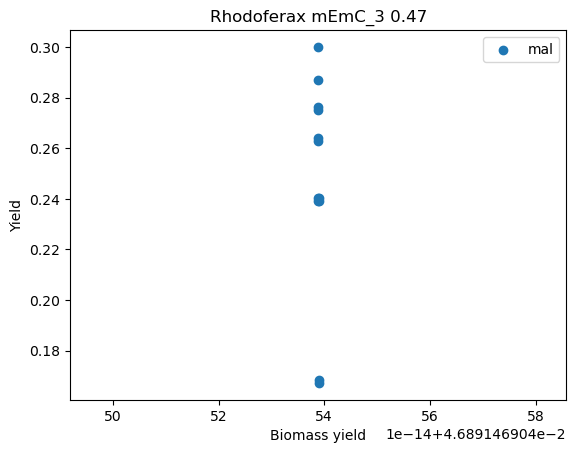

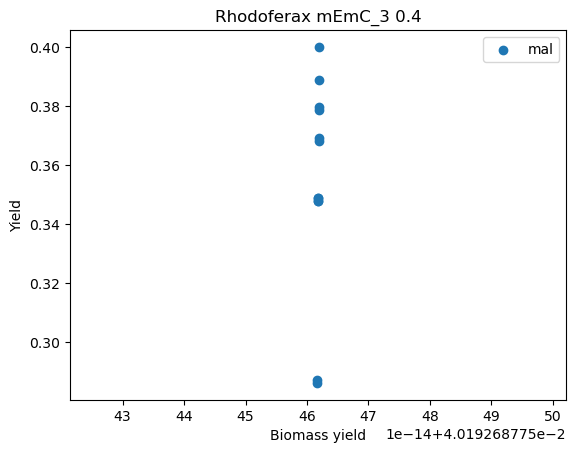

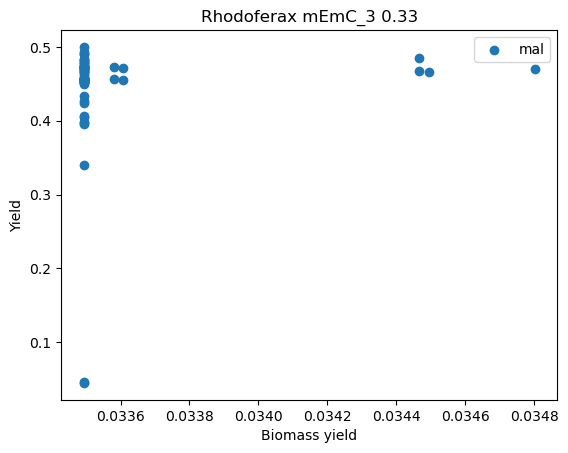

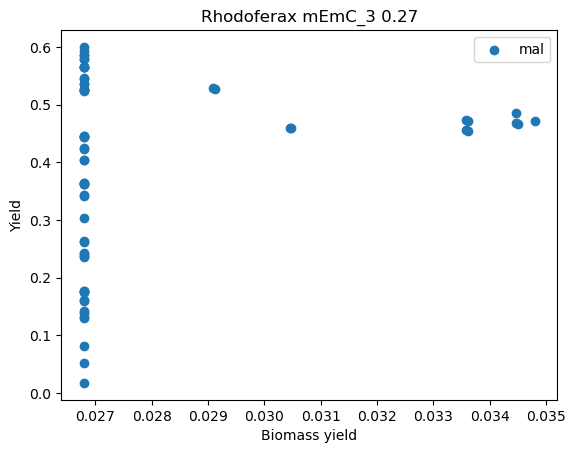

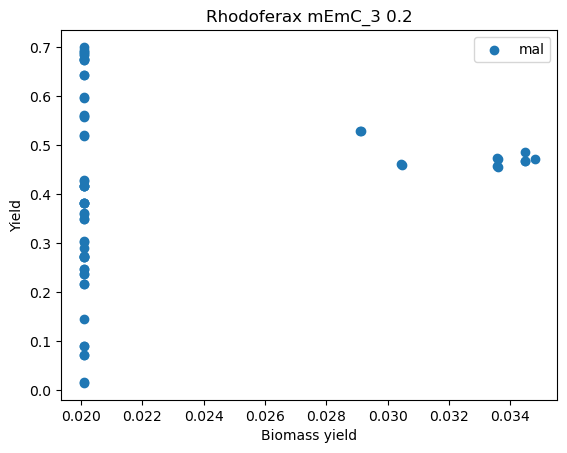

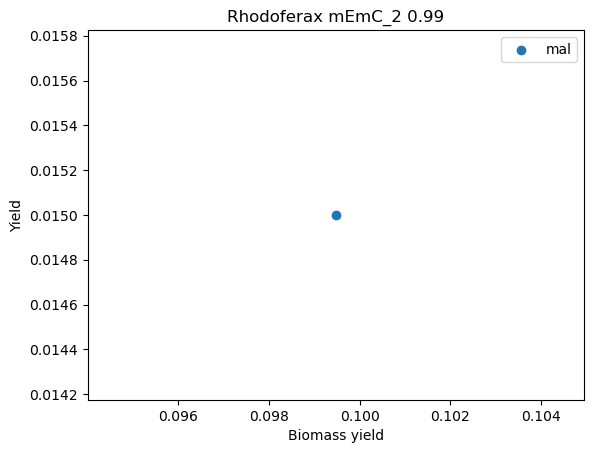

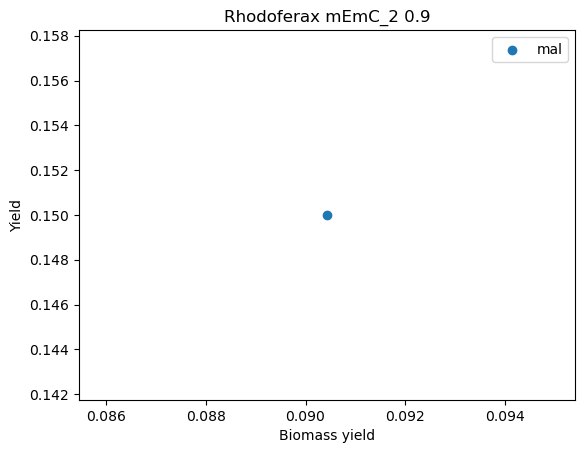

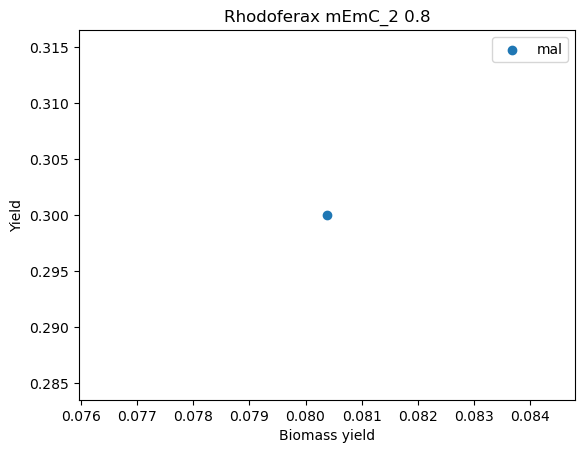

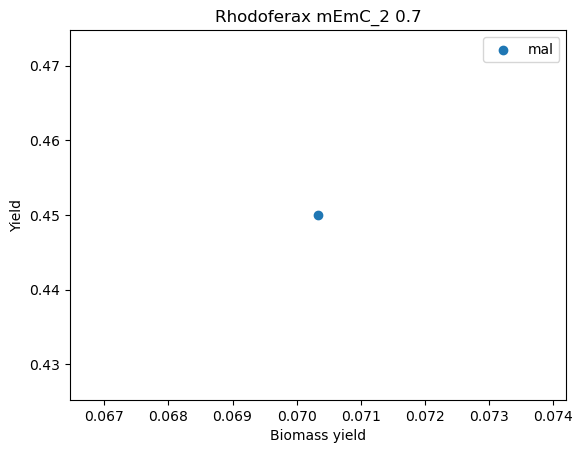

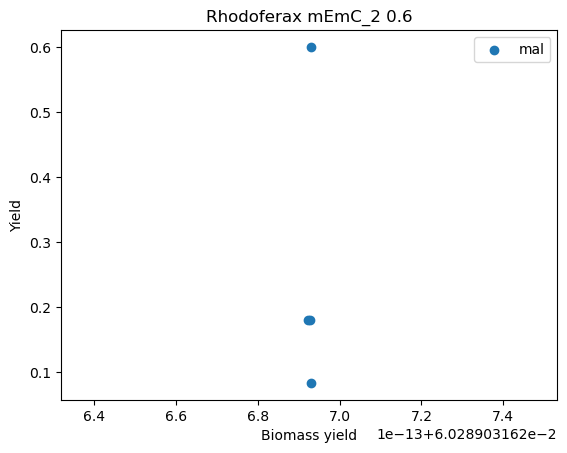

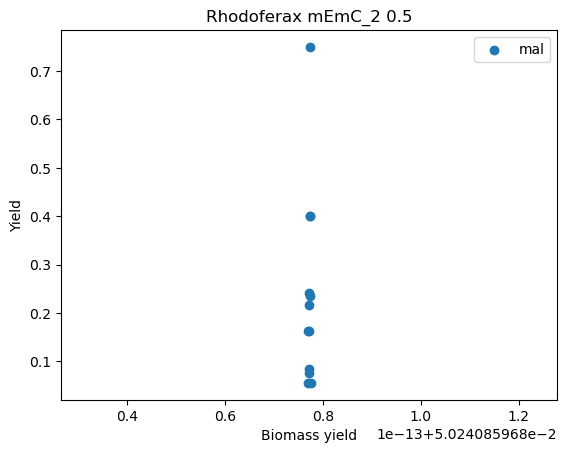

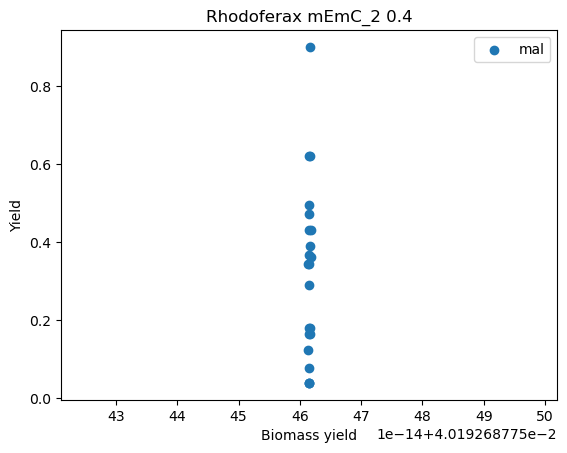

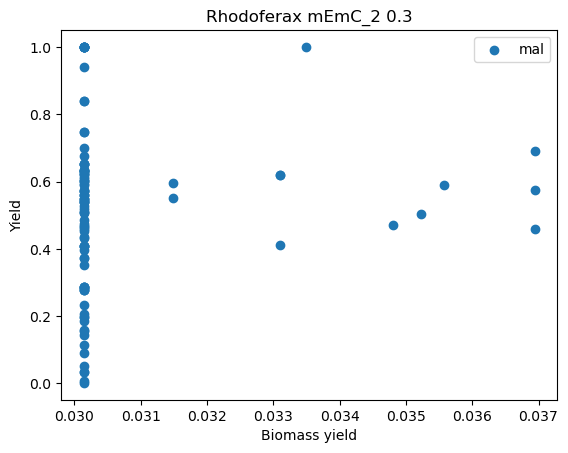

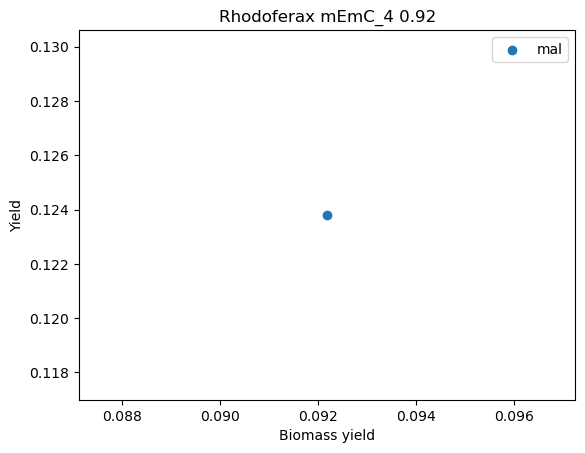

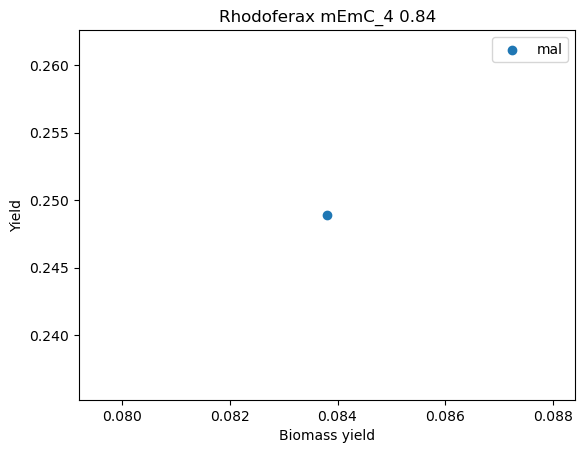

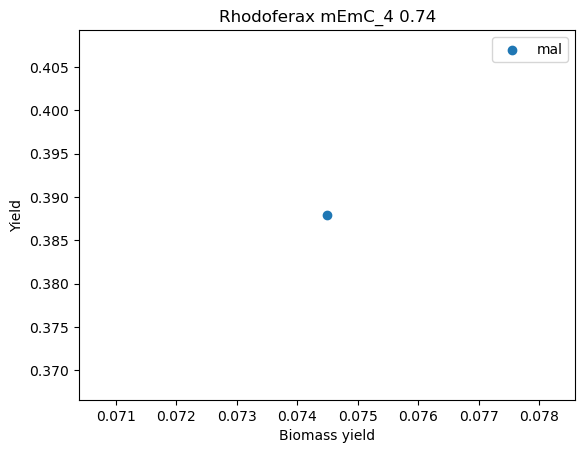

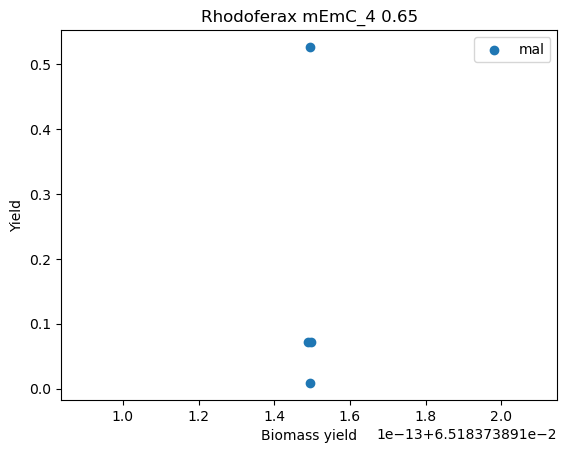

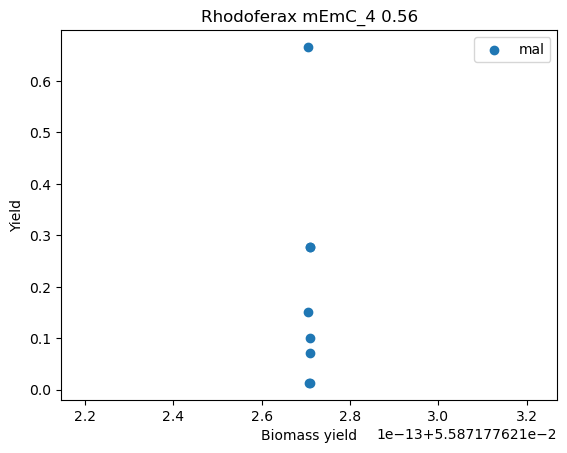

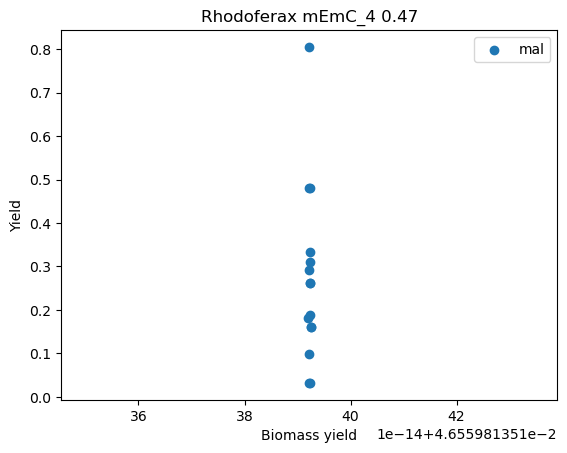

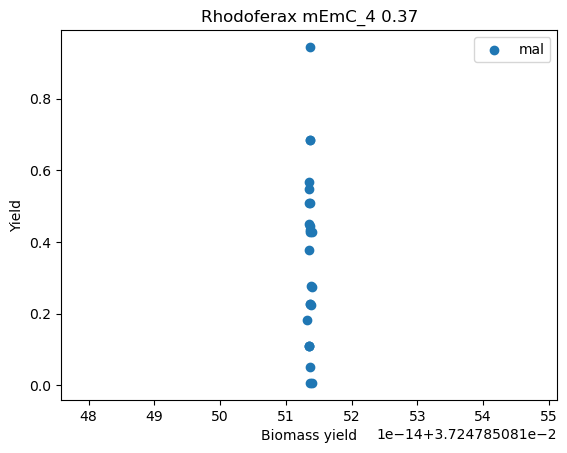

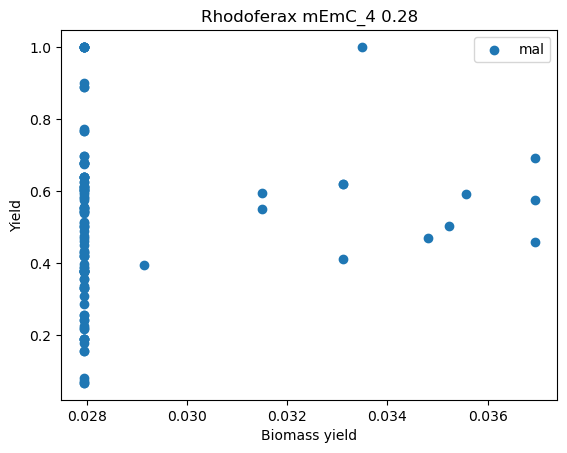

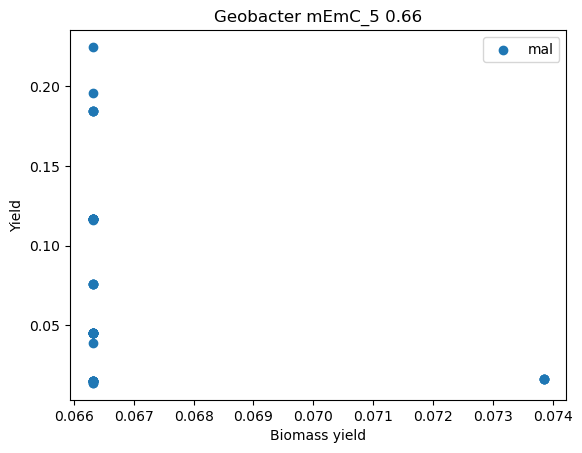

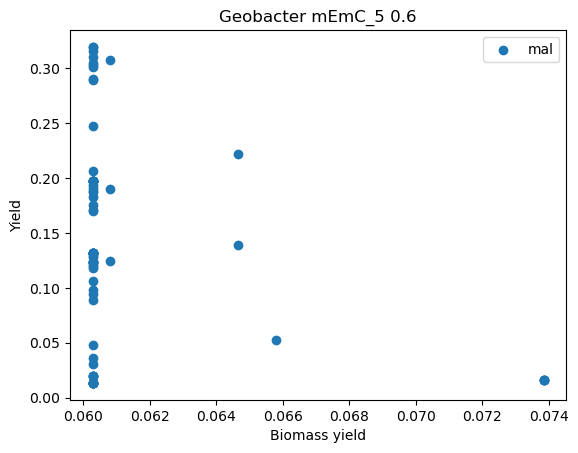

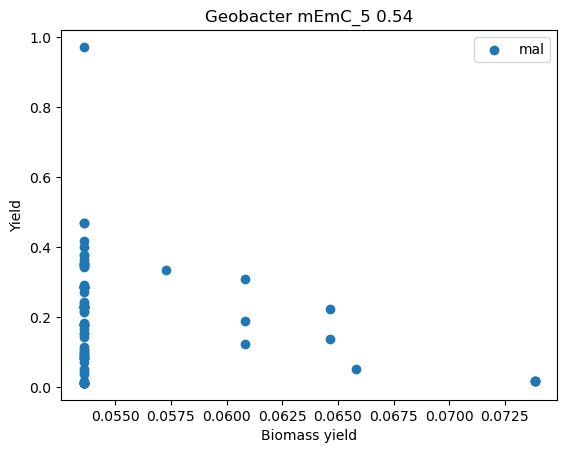

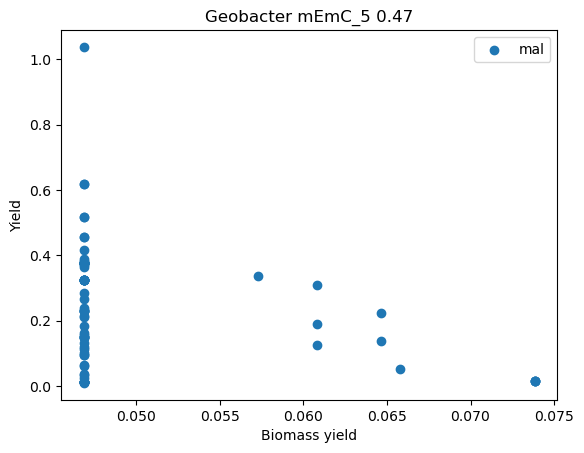

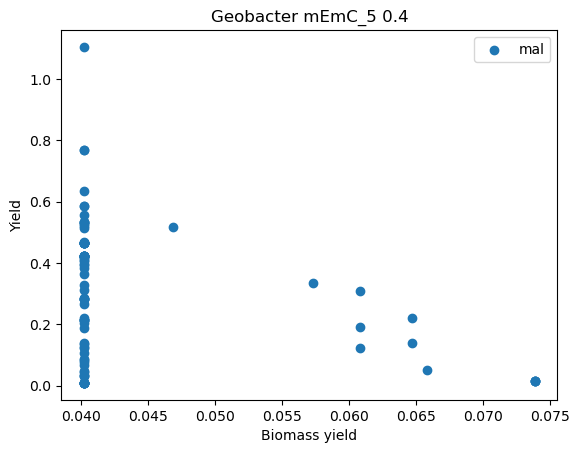

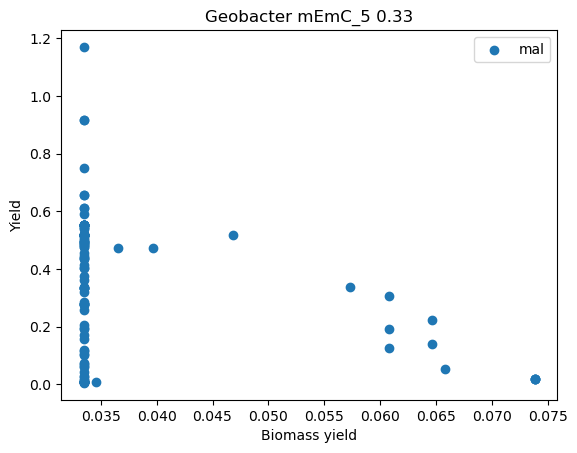

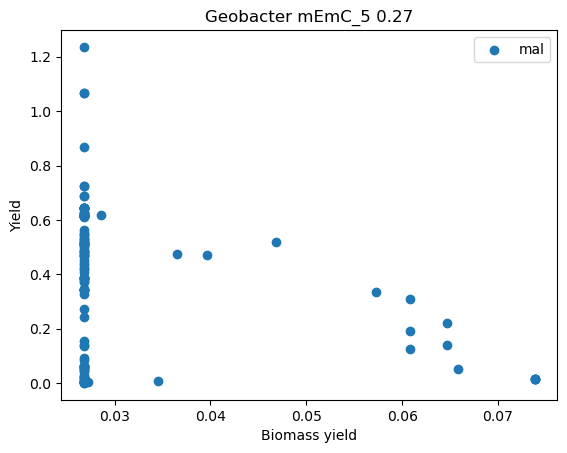

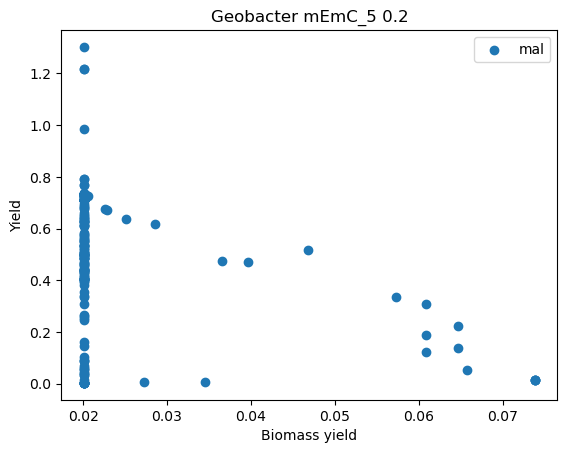

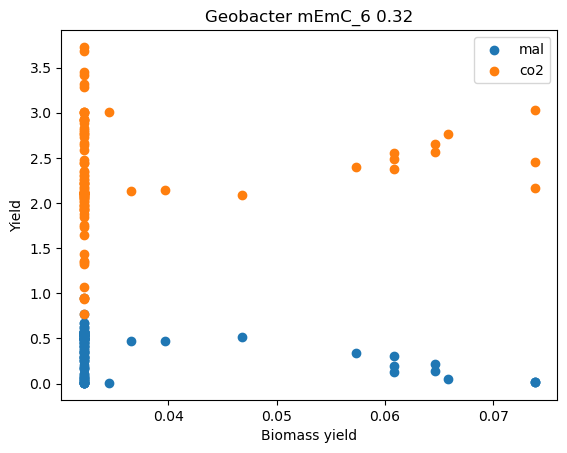

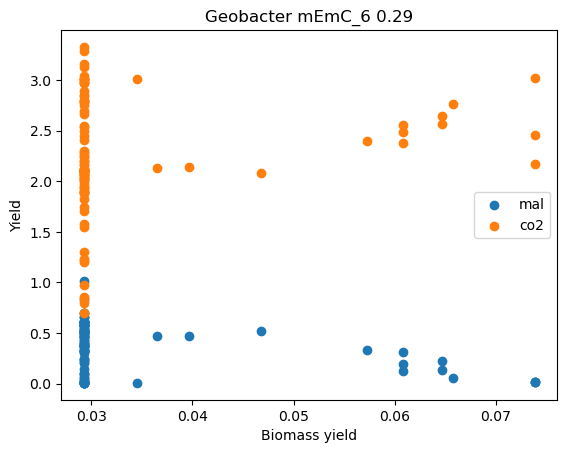

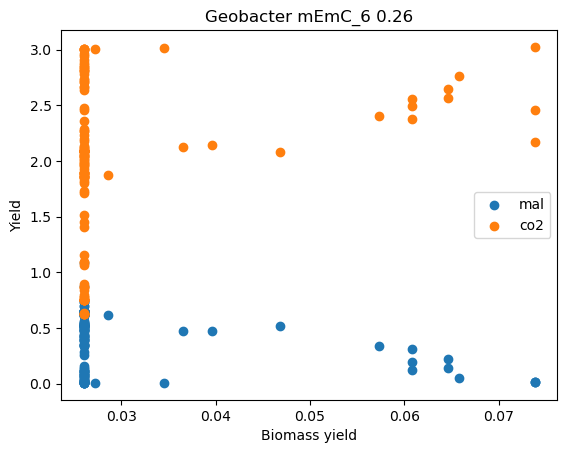

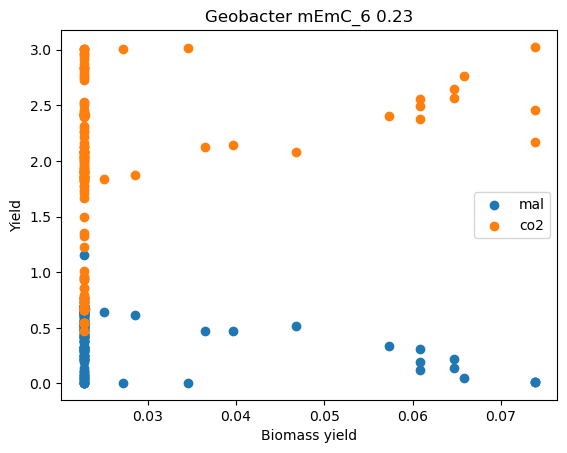

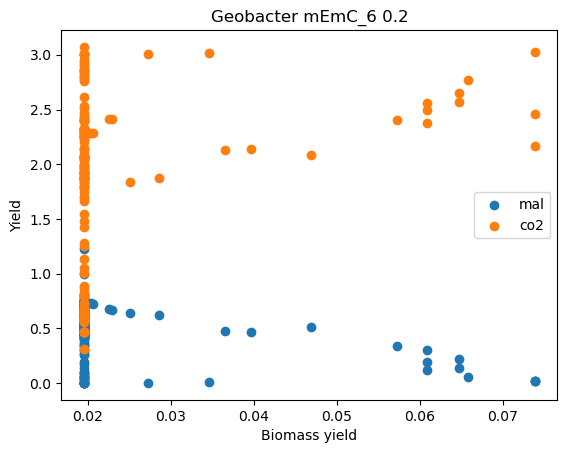

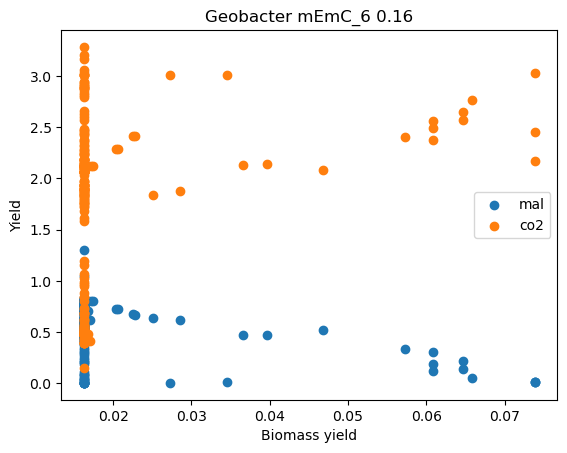

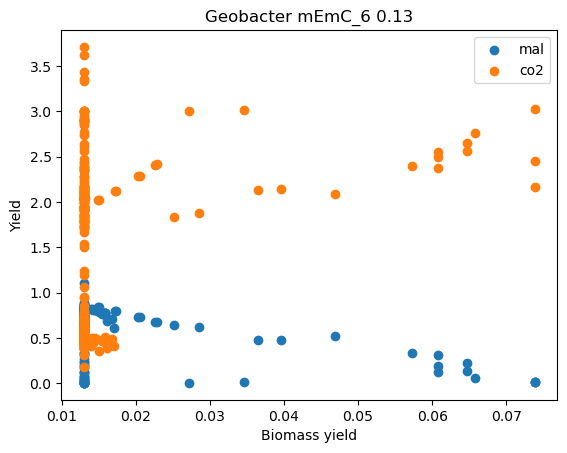

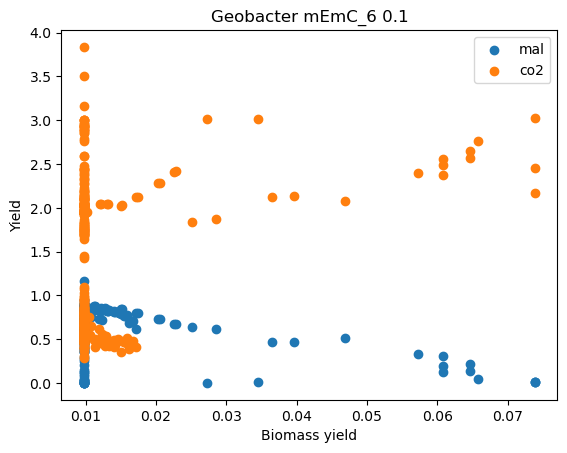

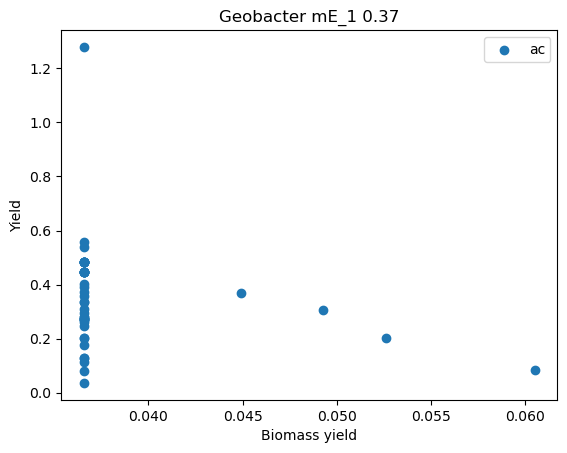

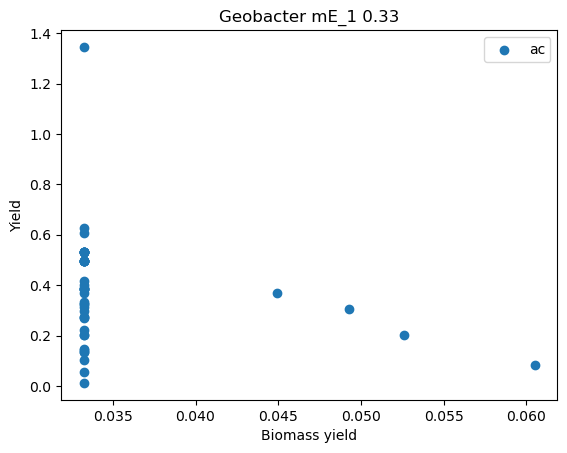

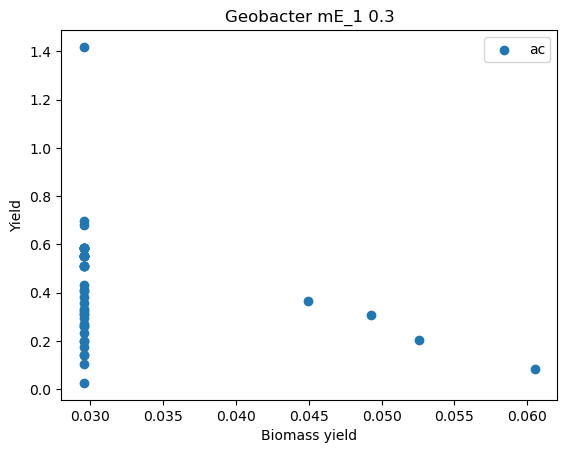

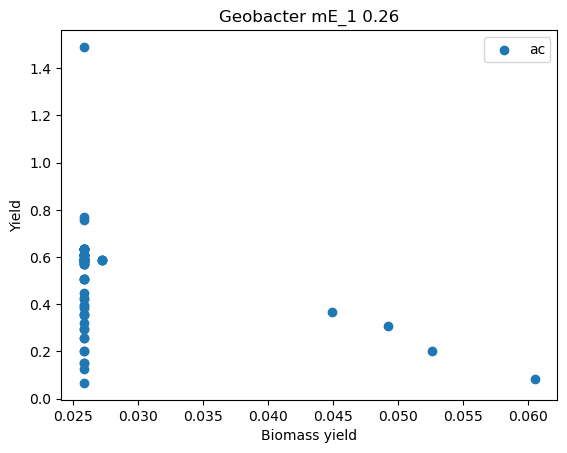

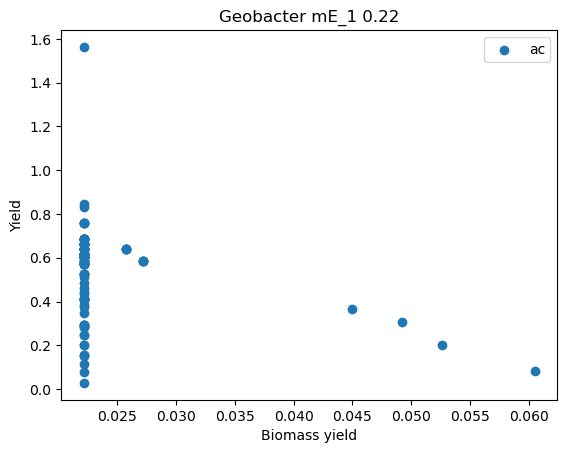

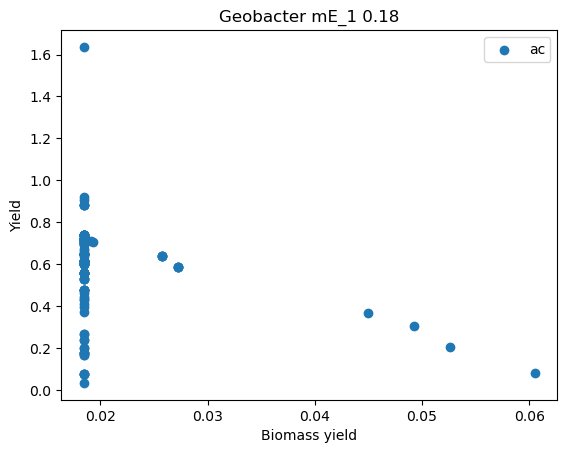

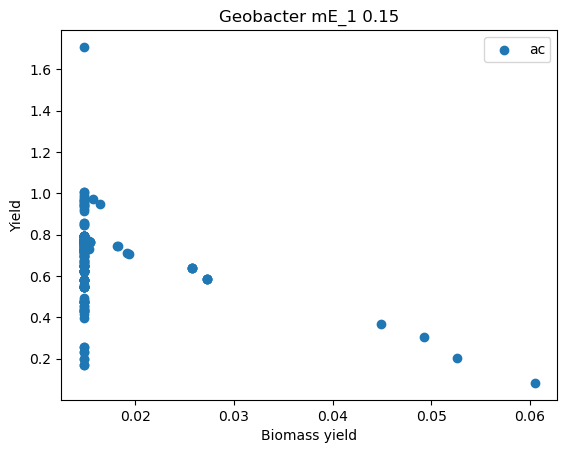

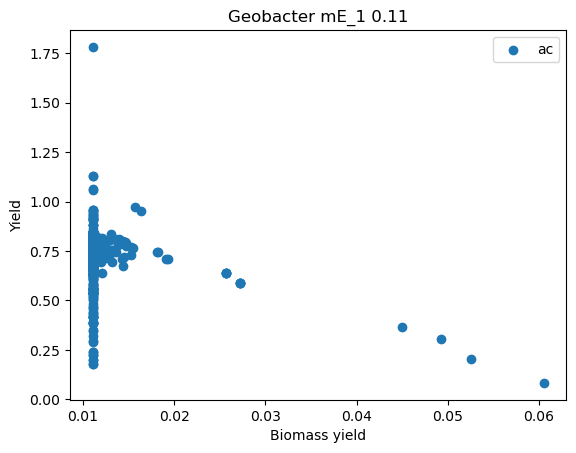

In [6]:
for organism, patterns in converted_pattern.items():
    for pattern_name, pattern in patterns.items():
        c_source = c_sources[organism][pattern_name]
        secretions = pattern["secretion"]
        if not secretions:
            continue

        for mu, ecms in filtered_ecms[organism][pattern_name].items():
            for met in secretions:
                sec_yield = ecms[met] / ecms[c_source]
                bio_yield = ecms["objective"] / ecms[c_source]
                sec_name = re.sub(r"M_|__45__L|_e", "", met)

                plt.scatter(abs(bio_yield), abs(sec_yield), label=sec_name)

            plt.xlabel("Biomass yield")
            plt.ylabel("Yield")
            plt.title(f"{organism} {pattern_name} {mu}")
            plt.legend()
            plt.show()

In [7]:
crossfed_combos = {"mEmC_1": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_2": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_3": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_4": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_5": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_6": ["M_mal__45__L_e", "M_co2_e",  "M_fe2_e"],
          "mE_1": ["M_ac_e"]}

In [8]:
for organism in ["Rhodoferax", "Geobacter"]:
    print(organism)
    for pattern, crossfed in crossfed_combos.items():
        for mu, ecms in filtered_ecms[organism][pattern].items():
            rho_p = ecms[crossfed[0]]
            rho_c = ecms[c_sources[organism][pattern]]
        
            print(f"{mu:.2f}: {min(abs(rho_p/rho_c)):.3f}-{max(abs(rho_p/rho_c)):.2f}")

Rhodoferax
0.66: 0.010-0.01
0.60: 0.022-0.10
0.54: 0.048-0.20
0.47: 0.167-0.30
0.40: 0.286-0.40
0.33: 0.045-0.50
0.27: 0.017-0.60
0.20: 0.014-0.70
0.99: 0.015-0.02
0.90: 0.150-0.15
0.80: 0.300-0.30
0.70: 0.450-0.45
0.60: 0.083-0.60
0.50: 0.056-0.75
0.40: 0.038-0.90
0.30: 0.001-1.00
0.66: 0.010-0.01
0.60: 0.022-0.10
0.54: 0.048-0.20
0.47: 0.167-0.30
0.40: 0.286-0.40
0.33: 0.045-0.50
0.27: 0.017-0.60
0.20: 0.014-0.70
0.92: 0.124-0.12
0.84: 0.249-0.25
0.74: 0.388-0.39
0.65: 0.009-0.53
0.56: 0.013-0.67
0.47: 0.032-0.80
0.37: 0.007-0.94
0.28: 0.068-1.00
0.66: 1.000-1.00
0.60: 1.000-1.00
0.54: 1.000-1.00
0.47: 1.000-1.00
0.40: 1.000-1.00
0.33: 1.000-1.00
0.27: 1.000-1.00
0.20: 1.000-1.00
0.32: 1.000-1.00
0.29: 1.000-1.00
0.26: 1.000-1.00
0.23: 1.000-1.00
0.20: 1.000-1.00
0.16: 1.000-1.00
0.13: 1.000-1.00
0.10: 1.000-1.00
0.37: 1.000-1.00
0.33: 1.000-1.00
0.30: 1.000-1.00
0.26: 1.000-1.00
0.22: 1.000-1.00
0.18: 1.000-1.00
0.15: 1.000-1.00
0.11: 1.000-1.00
Geobacter
0.66: 1.000-1.00
0.60: 1.00

### Combine both species' ECMs into one exchange-only system

To find community modes, both species' filtered ECMs become "reactions" in one combined stoichiometric matrix over their shared exchanged metabolites, plus one slack "exchange reaction" per metabolite so the whole system can be solved as equalities (what efmtool requires).

In [9]:
def combine_ecms(ecms1, ecms2, allowed_uptakes):
    df1_t = ecms1.T
    df2_t = ecms2.T

    # union of all exchanged metabolites (rows), missing entries filled with 0
    all_keys = df1_t.index.union(df2_t.index)
    df1_ext = df1_t.reindex(all_keys, fill_value=0)
    df2_ext = df2_t.reindex(all_keys, fill_value=0)

    # combine side-by-side as columns
    combined = pd.concat([df1_ext, df2_ext], axis=1, keys=["df1", "df2"])
    combined = combined[combined.index != "objective"]

    n1 = df1_ext.shape[1]
    n2 = df2_ext.shape[1]
    combined.columns = [f"ECM1-{i + 1}" for i in range(n1)] + [f"ECM2-{i + 1}" for i in range(n2)]

    # one slack "exchange reaction" per metabolite: reversible (can be taken up
    # from the environment) only if it's in allowed_uptakes, irreversible otherwise
    identity = pd.DataFrame(-np.eye(len(combined)), index=combined.index, columns=combined.index)
    identity.columns = [f"S_{i.replace('M_', '')}" for i in combined.index]

    combined_slack = pd.concat([combined, identity], axis=1)
    return combined, combined_slack

### Build the efmtool input per pattern and growth rate

`allowed_uptakes` are metabolites either species may freely take up from the environment - they get a reversible slack reaction. Everything else exchanged between the two species is a cross-fed metabolite and must balance between them exactly, so it gets an irreversible slack reaction instead.

Cross-fed metabolites can't be read off `exchange_pattern` directly: some (e.g. `fe2_e`, secreted by Geobacter) are never listed there at all - they're simply left open by the background exchange list from `make_ecmtool_inputs.ipynb`, which isn't part of `run_metadata`. Instead, they're identified directly from the ECM data: a metabolite is cross-fed if one species only secretes it (positive flux) while the other only takes it up (negative flux).

In [10]:
efmtool_inputs = {}

for pattern_name, growth_rates in filtered_ecms["Geobacter"].items():
    efmtool_inputs[pattern_name] = {}

    for mu, ecms_geo in growth_rates.items():
        ecms_rho = filtered_ecms["Rhodoferax"][pattern_name][mu]

        uptake_geo = set(ecms_geo.columns[(ecms_geo < 0).any(axis=0)])
        uptake_rho = set(ecms_rho.columns[(ecms_rho < 0).any(axis=0)])
        secreted_geo = set(ecms_geo.columns[(ecms_geo > 0).any(axis=0)])
        secreted_rho = set(ecms_rho.columns[(ecms_rho > 0).any(axis=0)])

        crossfed = crossfed_combos[pattern_name]
        allowed_uptakes = (uptake_geo | uptake_rho) - set(crossfed)

        combined, combined_slack = combine_ecms(ecms_geo, ecms_rho, allowed_uptakes)

        matrix = np.array(combined_slack)
        mets = list(combined.index)
        rxns = list(combined_slack.columns)
        revs = [0] * combined.shape[1] + [1 if met in allowed_uptakes else 0 for met in combined_slack.index]

        efmtool_inputs[pattern_name][mu] = (matrix, revs, rxns, mets)

### Run efmtool and derive community composition

Runs efmtool once per pattern/growth rate. Already-computed results are skipped (`ecms2comp_*.csv` present), so this can be safely re-run after an interruption. Only the full exchange-flux table for the highest tested growth rate per pattern is kept (`ecms2exs_*.csv`, `index == 0`) - lower growth rates can have far more EFMs, and only their composition summary is needed. efmtool has occasionally failed at runtime for very large inputs (low growth rate, many EFMs); those cases are logged and skipped rather than crashing the whole loop.

In [11]:
options = efmtool.get_default_options()
options["level"] = "WARNING"

failed = []

for pattern_name, one_pattern in efmtool_inputs.items():
    mus = sorted((float(k) for k in one_pattern.keys()), reverse=True)

    for index, mu in enumerate(mus):
        print(f"Running {pattern_name} {mu}")

        # runtime error in this case
        if (pattern_name == "mE_1") and (index == 7):
            continue

        try:
            _ = pd.read_csv(f"../results/ecms2comp_{pattern_name}_{mu}.csv")
            print(" * already done")
            continue
        except FileNotFoundError:
            pass

        matrix, revs, rxns, mets = one_pattern[mu]

        try:
            efms_array = efmtool.calculate_efms(matrix, revs, rxns, mets, options)
        except Exception as e:
            print(f" * efmtool failed for {pattern_name} {mu}: {e}")
            failed.append((pattern_name, mu))
            continue

        print(f"{efms_array.shape[1]} EFMs")

        efms_nice = pd.DataFrame(efms_array, index=rxns)
        efms_nice = efms_nice.div(efms_nice.loc["S_virtual_tag_R_constraint_reaction"])
        if index == 0:
            efms_nice.to_csv(f"../results/ecms2exs_{pattern_name}_{mu}.csv")

        efms = efms_nice[efms_nice.index.str.startswith("ECM")]
        ecm1_frac = efms[efms.index.str.startswith("ECM1")].sum(axis=0)
        ecm2_frac = efms[efms.index.str.startswith("ECM2")].sum(axis=0)

        composition = pd.DataFrame({"Geobacter": ecm1_frac, "Rhodoferax": ecm2_frac})
        composition.to_csv(f"../results/ecms2comp_{pattern_name}_{mu}.csv")



Running mEmC_1 0.66
 * already done
Running mEmC_1 0.6
 * already done
Running mEmC_1 0.54
 * already done
Running mEmC_1 0.47
 * already done
Running mEmC_1 0.4
 * already done
Running mEmC_1 0.33
 * already done
Running mEmC_1 0.27
 * already done
Running mEmC_1 0.2
 * already done
Running mEmC_2 0.99
 * already done
Running mEmC_2 0.9
 * already done
Running mEmC_2 0.8
 * already done
Running mEmC_2 0.7
 * already done
Running mEmC_2 0.6
 * already done
Running mEmC_2 0.5
 * already done
Running mEmC_2 0.4
 * already done
Running mEmC_2 0.3
 * already done
Running mEmC_3 0.66
 * already done
Running mEmC_3 0.6
 * already done
Running mEmC_3 0.54
 * already done
Running mEmC_3 0.47
 * already done
Running mEmC_3 0.4
 * already done
Running mEmC_3 0.33
 * already done
Running mEmC_3 0.27
 * already done
Running mEmC_3 0.2
 * already done
Running mEmC_4 0.92
 * already done
Running mEmC_4 0.84
 * already done
Running mEmC_4 0.74
 * already done
Running mEmC_4 0.65
 * already done
Runni